# Clustering of the Iris Dataset with K-Means

We are going to apply the K-Means method to the Iris dataset. This dataset has class labels, so it would be more appropriate to apply a supervised classification method. However, we are going to ignore the class labels and apply K-Means as clustering, comparing *a posteriori* the results obtained with the real labels.

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

print(iris.feature_names)
print(iris.data[:5])
print(iris.target_names)
print(iris.target[:5])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
['setosa' 'versicolor' 'virginica']
[0 0 0 0 0]


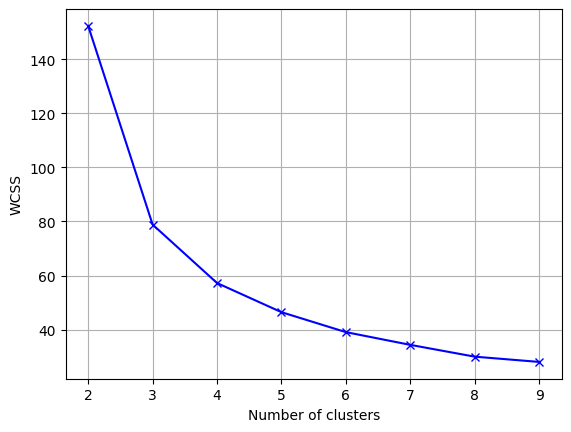

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2,10)
for n_clusters in K:
    model = KMeans(n_clusters, n_init = 20).fit(iris.data)
    inertia.append(model.inertia_)
    
plt.plot(K, inertia, 'bx-')
plt.xticks(K)
plt.grid(True)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

With the default values n_init='auto' and init='k-means++', [the number of iterations is 1](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). It can be observed that without setting the seed, the representation in this case varies a lot. This is because the K-Means algorithm is sensitive to the initialization of the centroids and is not managing to converge to a global minimum in some cases. By increasing the number of iterations, it can be observed that the representation is more stable, which is why n_init=100 has been set.

Once the graph is stable, the slope changes between 3 and 10 are quite continuous, which shows how subjective the choice of the number of clusters is with this method.

## Comparison of results obtained with real labels

We will define a function that represents each real class with different markers and each obtained cluster with colors based on a k value that it receives as a parameter. Since there are 4 dimensions, we'll represent those that we know correlate most with the real class, as indicated in the documentation (in iris.DESCR):

```
============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================
```

In [ ]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_compare_iris_n_clusters(n_clusters):
    y = KMeans(n_clusters, n_init = 20).fit_predict(iris.data) # Train the model and predict clusters
    
    iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names) # Create a DataFrame with the data to use in Seaborn
    iris_df['species'] = iris.target_names[iris.target] # Add the species of each flower with its name
    iris_df['cluster'] = y # Add the cluster assigned to each flower

    sns.scatterplot(x='petal length (cm)', y='petal width (cm)',
                    hue='cluster', # The color depends on the cluster
                    palette='Set1',
                    style='species', # The style depends on the species
                    data=iris_df)

    plt.xlabel('Petal Length (cm)')
    plt.ylabel('Petal Width (cm)')
    plt.show()

Running for 5 clusters:

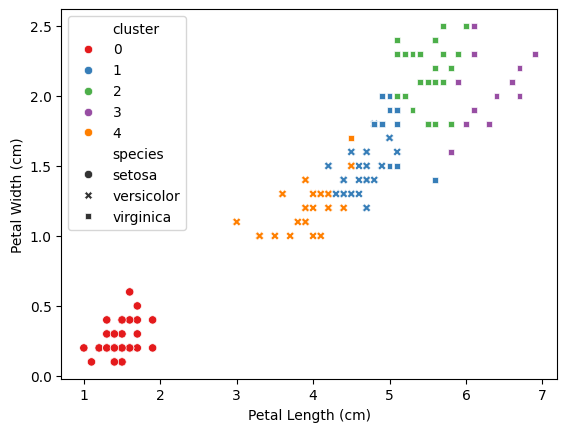

In [ ]:
plot_compare_iris_n_clusters(5)

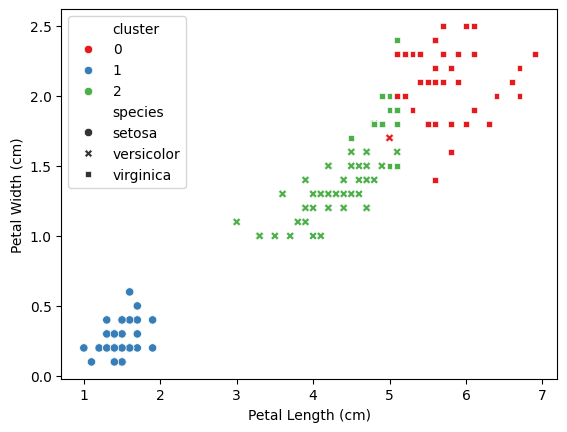

In [ ]:
plot_compare_iris_n_clusters(3)

We see that the result is quite similar. We could calculate the performance of the clustering with respect to the real labels as if it were a classification.

Since we know that there are actually 3 categories, we are going to compare the results obtained for 3 clusters. The number assigned to each cluster does not necessarily match the number assigned to each real class, so in order to compare them, we are going to assign to each cluster the real class number that occurs most frequently in it.

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42).fit(iris.data)
df = pd.DataFrame({'cluster': kmeans.labels_, 'real_class': iris.target_names[iris.target]})
df

,cluster,real_class
0,1,setosa
1,1,setosa
2,1,setosa
3,1,setosa
4,1,setosa
...,...,...
145,0,virginica
146,2,virginica
147,0,virginica
148,0,virginica


We calculate the mode of each cluster and assign to each cluster the real class number that occurs most frequently in it.

In [ ]:
modes = df.groupby('cluster')['real_class'].agg(pd.Series.mode)
modes

cluster
0     virginica
1        setosa
2    versicolor
Name: real_class, dtype: object

And we add the mode column of each cluster to our DataFrame (assuming there is a single clear mode in each cluster). It would be necessary to be more refined if there were ties, and it would be problematic if two clusters had the same mode.

In [ ]:
df['cluster_mode'] = df['cluster'].map(modes)
df

,cluster,real_class,cluster_mode
0,1,setosa,setosa
1,1,setosa,setosa
2,1,setosa,setosa
3,1,setosa,setosa
4,1,setosa,setosa
...,...,...,...
145,0,virginica,virginica
146,2,virginica,versicolor
147,0,virginica,virginica
148,0,virginica,virginica


And now that the same cluster number matches the same real class number, we can compare them as if it were a classification.

In [ ]:
from sklearn.metrics import classification_report

y_pred = KMeans(3, n_init = 20).fit_predict(iris.data)
print(classification_report(df.real_class, df.cluster_mode))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.77      0.94      0.85        50
   virginica       0.92      0.72      0.81        50

    accuracy                           0.89       150
   macro avg       0.90      0.89      0.89       150
weighted avg       0.90      0.89      0.89       150

